# Dataset

Let's import the necessary libraries and load the dataset.

In [14]:
import os

import brainstate as bst

import pinnx

Load the dataset from example directory.

In [15]:
PATH = os.path.abspath('.')
fname_train = os.path.join(PATH, '..', '..', 'examples','dataset', 'dataset.train')
fname_test = os.path.join(PATH, '..', '..', 'examples','dataset', 'dataset.test')


data = pinnx.data.DataSet(
    fname_train=fname_train,
    fname_test=fname_test,
    col_x=(0,),
    col_y=(1,),
    standardize=True,
)

Defines the neural network architecture using the pinnx.nn.FNN class.

In [17]:
layer_size = [1] + [50] * 3 + [1]
net = pinnx.nn.FNN(layer_size, "tanh", bst.init.KaimingUniform())

Initializes the model with the dataset and neural network.

In [18]:
model = pinnx.Model(data, net)

Compiles the model with an optimizer and metrics.

In [19]:
model.compile(bst.optim.Adam(0.001), metrics=["l2 relative error"])

Compiling model...
'compile' took 0.039188 s



Trains the model for a specified number of iterations.

In [20]:
losshistory, train_state = model.train(iterations=50000)

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.22e+00]    [1.26e+00]    [1.57e+00]    
1000      [6.82e-03]    [7.01e-03]    [1.17e-01]    
2000      [5.72e-03]    [6.10e-03]    [1.09e-01]    
3000      [5.32e-03]    [5.78e-03]    [1.06e-01]    
4000      [5.10e-03]    [5.62e-03]    [1.05e-01]    
5000      [4.94e-03]    [5.50e-03]    [1.04e-01]    
6000      [4.83e-03]    [5.37e-03]    [1.03e-01]    
7000      [4.77e-03]    [5.28e-03]    [1.02e-01]    
8000      [4.75e-03]    [5.23e-03]    [1.01e-01]    
9000      [4.73e-03]    [5.22e-03]    [1.01e-01]    
10000     [4.72e-03]    [5.23e-03]    [1.01e-01]    
11000     [4.88e-03]    [5.50e-03]    [1.04e-01]    
12000     [4.71e-03]    [5.23e-03]    [1.01e-01]    
13000     [4.70e-03]    [5.20e-03]    [1.01e-01]    
14000     [4.68e-03]    [5.17e-03]    [1.01e-01]    
15000     [4.66e-03]    [5.17e-03]    [1.01e-01]    
16000     [4.64e-03]    [5.23e-03]    [1.01e-01]    
17000     [3.68e-03]    [4.

Saves and plots the training loss history and state.

Saving loss history to c:\Github\pinnx\docs\function\loss.dat ...
Saving training data to c:\Github\pinnx\docs\function\train.dat ...
Saving test data to c:\Github\pinnx\docs\function\test.dat ...


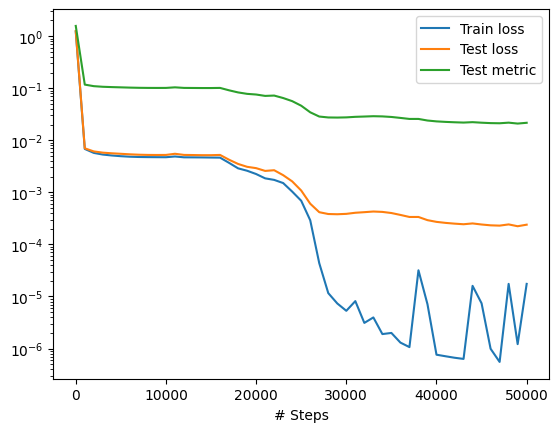

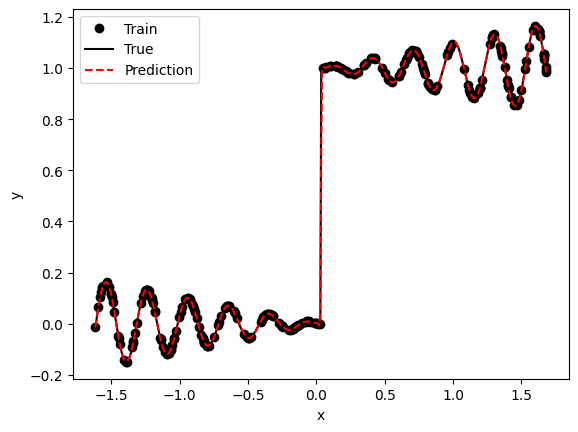

In [21]:
pinnx.saveplot(losshistory, train_state, issave=True, isplot=True)